In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Suporte a CUDA:", tf.test.is_built_with_cuda())
print("GPUs disponíveis:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Suporte a CUDA: True
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
base_model.trainable = False

print("MobileNetV2 carregada:", base_model.name)
print("Parâmetros:", base_model.count_params())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 carregada: mobilenetv2_1.00_224
Parâmetros: 2257984


In [1]:
import sys, json, csv, hashlib, shutil, subprocess, tempfile, uuid
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ['Capacete', 'Colete', 'Pessoa']
EPOCHS = 10
assert tf.test.is_built_with_cuda(), 'TensorFlow sem suporte a CUDA.'
assert tf.config.list_physical_devices('GPU'), 'Selecione GPU nas configurações do Colab e reconecte.'
gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True, check=True).stdout
print('Python:', sys.version)
print('TensorFlow:', tf.__version__)
print('Keras:', tf.keras.__version__)
print('CUDA:', tf.test.is_built_with_cuda())
print('GPUs:', tf.config.list_physical_devices('GPU'))
print(gpu_info)


Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
TensorFlow: 2.20.0
Keras: 3.13.2
CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mon Sep  7 17:13:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       3MiB /

In [2]:
from google.colab import files
from zipfile import ZipFile
from pathlib import PurePosixPath

uploaded = files.upload()
assert len(uploaded) == 1, 'Envie somente dataset_aula6_colab.zip.'
zip_name, zip_bytes = next(iter(uploaded.items()))
DATASET_SHA256 = hashlib.sha256(zip_bytes).hexdigest()
assert DATASET_SHA256 == 'fe2a5beabd4188a9684da3555e2aae61775db30ffcf06a65514972aea33cacb5', 'O ZIP não corresponde ao pacote preparado. Confira o arquivo enviado.'
work_dir = Path(tempfile.mkdtemp(prefix='aula6_', dir='/content'))
zip_path = work_dir / 'dataset_aula6_colab.zip'
zip_path.write_bytes(zip_bytes)
with ZipFile(zip_path) as archive:
    for member in archive.infolist():
        relative = PurePosixPath(member.filename)
        assert not relative.is_absolute() and '..' not in relative.parts, 'Caminho inválido no ZIP.'
        assert relative.parts[0] == 'aula6_classificacao', 'Raiz inesperada no ZIP.'
    archive.extractall(work_dir)
DATASET_ROOT = work_dir / 'aula6_classificacao'
assert DATASET_ROOT.is_dir()
del uploaded, zip_bytes
print('Dataset extraído em:', DATASET_ROOT)
print('SHA256:', DATASET_SHA256)


Saving dataset_aula6_colab.zip to dataset_aula6_colab.zip
Dataset extraído em: /content/aula6_g9w26zul/aula6_classificacao
SHA256: fe2a5beabd4188a9684da3555e2aae61775db30ffcf06a65514972aea33cacb5


In [3]:
with (DATASET_ROOT / 'manifesto_dataset.csv').open() as f:
    manifesto = list(csv.DictReader(f))
assert len(manifesto) == 584
expected = {'train': {'Capacete': 143, 'Colete': 125, 'Pessoa': 202},
            'validation': {'Capacete': 46, 'Colete': 24, 'Pessoa': 44}}
actual_files = {str(p.relative_to(DATASET_ROOT)) for p in DATASET_ROOT.rglob('*.png')}
assert actual_files == {r['file'] for r in manifesto}, 'Arquivos e manifesto divergentes.'
pixel_sets = {'train': set(), 'validation': set()}
source_sets = {'train': set(), 'validation': set()}
for row in manifesto:
    path = DATASET_ROOT / row['file']
    assert hashlib.sha256(path.read_bytes()).hexdigest() == row['sha256'], path
    with Image.open(path) as im:
        im.load()
        assert im.mode == 'RGB' and min(im.size) >= 12
        digest = hashlib.sha256(str(im.size).encode() + im.tobytes()).hexdigest()
        assert digest == row['pixel_sha256']
    pixel_sets[row['split']].add(digest)
    source_sets[row['split']].add(row['source_sha256'])
assert pixel_sets['train'].isdisjoint(pixel_sets['validation']), 'Recorte repetido entre splits.'
assert source_sets['train'].isdisjoint(source_sets['validation']), 'Imagem de origem repetida entre splits.'
structure = [str(DATASET_ROOT) + '/']
for split in ['train', 'validation']:
    assert sorted(p.name for p in (DATASET_ROOT / split).iterdir() if p.is_dir()) == CLASSES
    structure.append(f'  {split}/')
    for name in CLASSES:
        count = len(list((DATASET_ROOT / split / name).glob('*.png')))
        assert count == expected[split][name]
        structure.append(f'    {name}/ — {count} imagens PNG')
    structure.append(f'    TOTAL: {sum(expected[split].values())}')
structure_text = '\n'.join(structure)
print(structure_text)
print('AUDITORIA APROVADA: 584 recortes RGB; hashes corretos; sem duplicatas exatas entre splits.')
print('Pare aqui no primeiro acesso e envie esta saída ao assistente.')

/content/aula6_g9w26zul/aula6_classificacao/
  train/
    Capacete/ — 143 imagens PNG
    Colete/ — 125 imagens PNG
    Pessoa/ — 202 imagens PNG
    TOTAL: 470
  validation/
    Capacete/ — 46 imagens PNG
    Colete/ — 24 imagens PNG
    Pessoa/ — 44 imagens PNG
    TOTAL: 114
AUDITORIA APROVADA: 584 recortes RGB; hashes corretos; sem duplicatas exatas entre splits.
Pare aqui no primeiro acesso e envie esta saída ao assistente.


Found 470 files belonging to 3 classes.
Found 114 files belonging to 3 classes.
Classes: {0: 'Capacete', 1: 'Colete', 2: 'Pessoa'}
Batch: (32, 224, 224, 3) Rótulos: (32,)


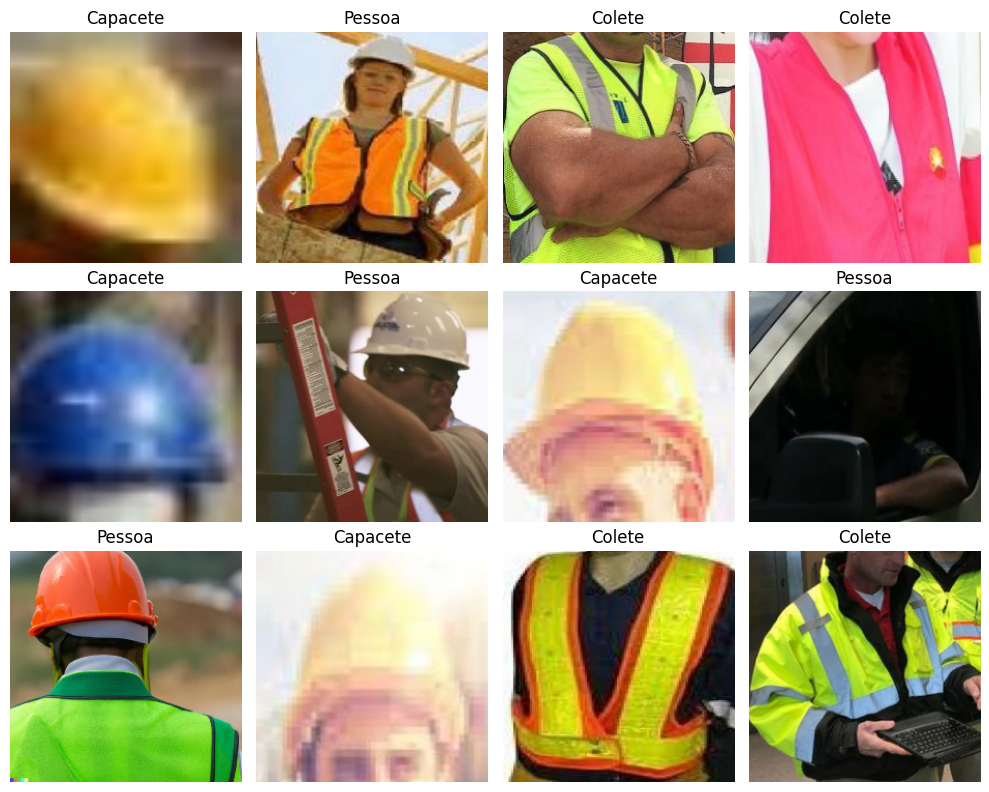

In [4]:
tf.keras.utils.set_random_seed(SEED)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / 'train', class_names=CLASSES, label_mode='int',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode='rgb', shuffle=True, seed=SEED)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / 'validation', class_names=CLASSES, label_mode='int',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode='rgb', shuffle=False)
assert train_ds.class_names == val_ds.class_names == CLASSES
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
sample_images, sample_labels = next(iter(train_ds))
print('Classes:', dict(enumerate(CLASSES)))
print('Batch:', sample_images.shape, 'Rótulos:', sample_labels.shape)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy().astype('uint8'))
    ax.set_title(CLASSES[int(sample_labels[i])])
    ax.axis('off')
plt.tight_layout()
plt.show()


In [5]:
assert tf.config.list_physical_devices('GPU'), 'GPU indisponível; não iniciar na CPU.'
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '_' + uuid.uuid4().hex[:8]
RUN_DIR = work_dir / 'resultados' / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=False)
with tf.device('/GPU:0'):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name='imagem_rgb')
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(len(CLASSES), activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='mobilenetv2_epi_aula6')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])
    probe = model(sample_images, training=False)
assert 'GPU:0' in probe.device.upper(), f'Saída não localizada na GPU: {probe.device}'
assert not base_model.trainable_variables
assert probe.shape == (sample_images.shape[0], len(CLASSES))
tf.debugging.assert_all_finite(probe, 'Probabilidades não finitas.')
np.testing.assert_allclose(tf.reduce_sum(probe, axis=1).numpy(), 1, atol=1e-5)
model.summary()
print('Dispositivo do batch de verificação:', probe.device)
print('Execução:', RUN_ID)
TRAINING_STARTED = False
TRAINING_COMPLETE = False
EVALUATION_COMPLETE = False
metadata = {'run_id': RUN_ID, 'python': sys.version, 'tensorflow': tf.__version__,
            'keras': tf.keras.__version__, 'build_info': tf.sysconfig.get_build_info(),
            'gpu': gpu_info, 'seed': SEED, 'classes': CLASSES, 'counts': expected,
            'dataset_sha256': DATASET_SHA256, 'image_size': IMG_SIZE,
            'batch_size': BATCH_SIZE, 'optimizer': 'Adam', 'learning_rate': 1e-3,
            'planned_epochs': EPOCHS, 'probe_device': probe.device}
(RUN_DIR / 'ambiente.json').write_text(json.dumps(metadata, indent=2, ensure_ascii=False, default=str))
(RUN_DIR / '02_estrutura_dataset.txt').write_text(structure_text)
shutil.copy2(DATASET_ROOT / 'manifesto_dataset.csv', RUN_DIR)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_epi_aula6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagem_rgb (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Dispositivo do batch de verificação: /job:localhost/replica:0/task:0/device:GPU:0
Execução: 20260907T172220Z_43b4f8ea


'/content/aula6_g9w26zul/resultados/20260907T172220Z_43b4f8ea/manifesto_dataset.csv'

In [6]:
assert not TRAINING_STARTED, 'Treino já iniciado nesta execução. Para recomeçar do zero, execute a célula 5.'
assert tf.config.list_physical_devices('GPU'), 'A GPU não está mais disponível.'
TRAINING_STARTED = True
csv_logger = tf.keras.callbacks.CSVLogger(str(RUN_DIR / 'historico_treinamento.csv'))
with tf.device('/GPU:0'):
    history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[csv_logger])
assert len(history.epoch) == 10
assert all(np.isfinite(values).all() for values in history.history.values())
TRAINING_COMPLETE = True
model.save(RUN_DIR / 'mobilenetv2_epi_epoca10.keras')
print('Execução:', RUN_ID)
print('Épocas concluídas: 10/10')
print(f"Acurácia treino — época 10: {history.history['accuracy'][-1]:.6f} ({history.history['accuracy'][-1]:.2%})")
print(f"Acurácia validação — época 10: {history.history['val_accuracy'][-1]:.6f} ({history.history['val_accuracy'][-1]:.2%})")

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6894 - loss: 0.7762 - val_accuracy: 0.8421 - val_loss: 0.3716
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9170 - loss: 0.2538 - val_accuracy: 0.8947 - val_loss: 0.2940
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9532 - loss: 0.1466 - val_accuracy: 0.9211 - val_loss: 0.1699
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9723 - loss: 0.1003 - val_accuracy: 0.9298 - val_loss: 0.1520
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9915 - loss: 0.0560 - val_accuracy: 0.9386 - val_loss: 0.1530
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.9979 - loss: 0.0378 - val_accuracy: 0.9211 - val_loss: 0.2135
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9979 - loss: 0.0253 - val_accuracy: 0.9386 - val_loss: 0.1516
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 1.0000 - loss: 0.0165 - val_accuracy: 0.9211 - v

In [7]:
assert TRAINING_COMPLETE, 'Conclua as 10 épocas antes de avaliar.'
with tf.device('/GPU:0'):
    val_loss, val_accuracy = model.evaluate(val_ds)
print('Execução:', RUN_ID)
print(f'Loss de validação: {val_loss:.6f}')
print(f'Acurácia de validação: {val_accuracy:.6f} ({val_accuracy:.2%})')
assert np.isfinite([val_loss, val_accuracy]).all()
assert abs(val_accuracy - history.history['val_accuracy'][-1]) < 1e-5, 'Avaliação diverge da época 10; conferir antes de concluir.'
EVALUATION_COMPLETE = True
report = f"""# Aula 6 — Resultados medidos

Execução: {RUN_ID}
Dataset: epi-v1 adaptado por recortes. Classes: {', '.join(CLASSES)}.
Treino: 470 recortes de 95 imagens; validação: 114 recortes de 20 imagens.
MobileNetV2/ImageNet congelada; cabeça Dense 128 + softmax; entrada 224x224 RGB.
Adam 1e-3; batch 32; semente 42; 10 épocas.
TensorFlow: {tf.__version__}; Keras: {tf.keras.__version__}.
GPU do batch de verificação: {probe.device}.
SHA256 do ZIP: {DATASET_SHA256}.

- Accuracy treino na época 10: {history.history['accuracy'][-1]:.6f}
- Val_accuracy na época 10: {history.history['val_accuracy'][-1]:.6f}
- Loss de model.evaluate(val_ds): {val_loss:.6f}
- Accuracy de model.evaluate(val_ds): {val_accuracy:.6f} ({val_accuracy:.2%})

Limitações: dataset pequeno e desbalanceado; recortes correlacionados dentro de uma imagem;
qualidade e rótulos herdados; algumas imagens pequenas/borradas; pessoas podem vestir EPIs.
As métricas representam classificação dos recortes, não detecção de objetos nem teste independente.
Link Colab e três capturas: anexar após salvar o notebook executado.
"""
(RUN_DIR / '05_resultados.md').write_text(report)
(RUN_DIR / 'metricas.json').write_text(json.dumps({
    'run_id': RUN_ID, 'epoch': 10, 'train_accuracy': history.history['accuracy'][-1],
    'val_accuracy_epoch10': history.history['val_accuracy'][-1],
    'evaluate_loss': val_loss, 'evaluate_accuracy': val_accuracy}, indent=2))


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.9298 - loss: 0.1850
Execução: 20260907T172220Z_43b4f8ea
Loss de validação: 0.184989
Acurácia de validação: 0.929825 (92.98%)


210

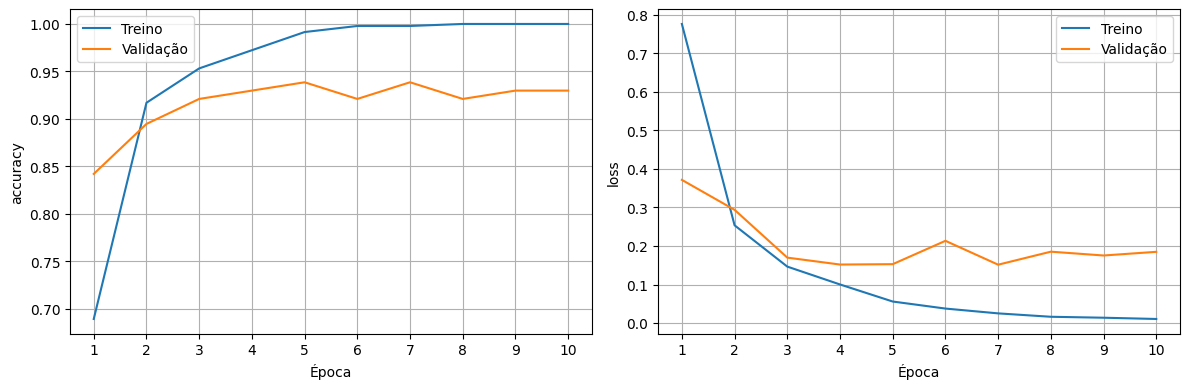

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Baixe também o notebook executado: Arquivo → Fazer download → .ipynb.
Salve o notebook no Drive com as saídas e confira o acesso de leitura para o professor.


In [8]:
assert EVALUATION_COMPLETE, 'Execute a avaliação antes de exportar.'
epochs_axis = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, metric in zip(axes, ['accuracy', 'loss']):
    axis.plot(epochs_axis, history.history[metric], label='Treino')
    axis.plot(epochs_axis, history.history['val_' + metric], label='Validação')
    axis.set(xlabel='Época', ylabel=metric, xticks=list(epochs_axis))
    axis.legend()
    axis.grid(True)
fig.tight_layout()
fig.savefig(RUN_DIR / 'curvas_treinamento.png', dpi=150)
plt.show()
export_zip = shutil.make_archive(str(work_dir / ('resultados_aula6_' + RUN_ID)), 'zip', RUN_DIR)
files.download(export_zip)
print('Baixe também o notebook executado: Arquivo → Fazer download → .ipynb.')
print('Salve o notebook no Drive com as saídas e confira o acesso de leitura para o professor.')

